# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [4]:
# Set some pandas options to make the tables easier to read
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [5]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [45]:
dfs = {
    'df_hh_income': df_hh_income,
    'df_pct_poverty': df_pct_poverty,
    'df_pct_completed_hs': df_pct_completed_hs,
    'df_share_race_city': df_share_race_city,
    'df_fatalities': df_fatalities
}
for df_name, df in dfs.items():
  print(f"Shape of {df_name}: {df.shape}")

Shape of df_hh_income: (29322, 3)
Shape of df_pct_poverty: (29329, 3)
Shape of df_pct_completed_hs: (29329, 3)
Shape of df_share_race_city: (29268, 7)
Shape of df_fatalities: (2535, 14)


In [47]:
for df_name, df in dfs.items():
  print(f"Columns of {df_name}: {df.columns}")



Columns of df_hh_income: Index(['Geographic Area', 'City', 'Median Income'], dtype='object')
Columns of df_pct_poverty: Index(['Geographic Area', 'City', 'poverty_rate'], dtype='object')
Columns of df_pct_completed_hs: Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='object')
Columns of df_share_race_city: Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='object')
Columns of df_fatalities: Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
       'flee', 'body_camera'],
      dtype='object')


In [48]:
for df_name, df in dfs.items():
  if df.isna().any().any():
    print(f"There are NaN values in {df_name}.")
  if df.duplicated().any():
    print(f"There are duplicated values in {df_name}.")

There are NaN values in df_pct_poverty.


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [54]:
df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'], errors='coerce')
df_hh_income.dropna(inplace=True)

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [ ]:
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce') # Convert poverty_rate to numeric, forcing errors to NaN
df_pct_poverty.dropna(inplace=True) # Drop rows with NaN values in poverty_rate
poverty_rate = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().sort_values(ascending=False).reset_index()

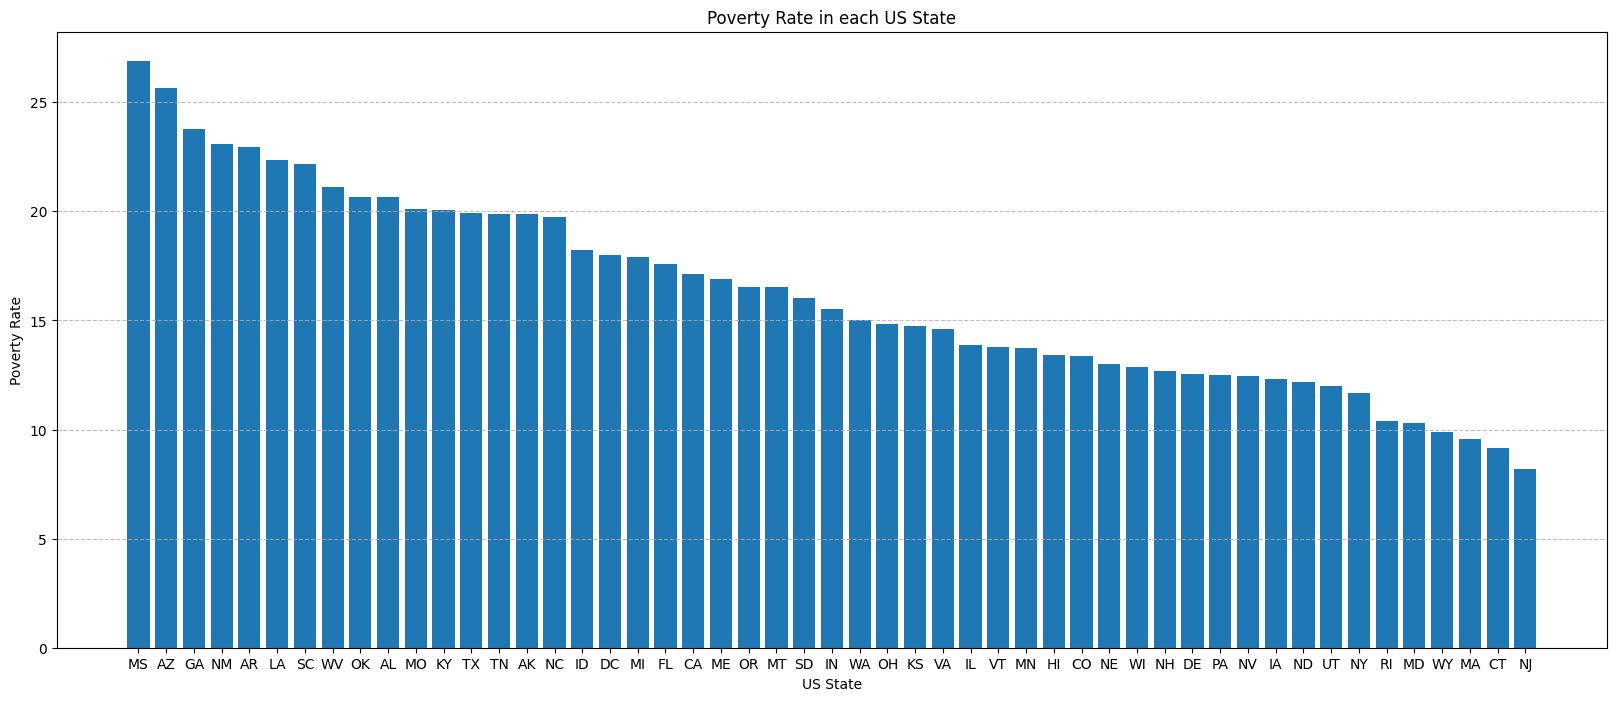

The state with the highest poverty rate is MS with a rate of 26.88%
The state with the lowest poverty rate is NJ with a rate of 8.19%


In [61]:
plt.figure(figsize=(20, 8))
plt.bar(poverty_rate['Geographic Area'], poverty_rate['poverty_rate'])
plt.xlabel("US State")
plt.ylabel("Poverty Rate")
plt.title("Poverty Rate in each US State")
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.show()

print(f'The state with the highest poverty rate is {poverty_rate.iloc[0]["Geographic Area"]} with a rate of {poverty_rate.iloc[0]["poverty_rate"]:.2f}%')
print(f'The state with the lowest poverty rate is {poverty_rate.iloc[-1]["Geographic Area"]} with a rate of {poverty_rate.iloc[-1]["poverty_rate"]:.2f}%')

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [77]:
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce') # Convert percent_completed_hs to numeric, forcing errors to NaN
df_pct_completed_hs.dropna(inplace=True) # Drop rows with NaN values in poverty_rate
completed_hs_rate = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().sort_values(ascending=True).reset_index() # Calculate average high school completion rate by state

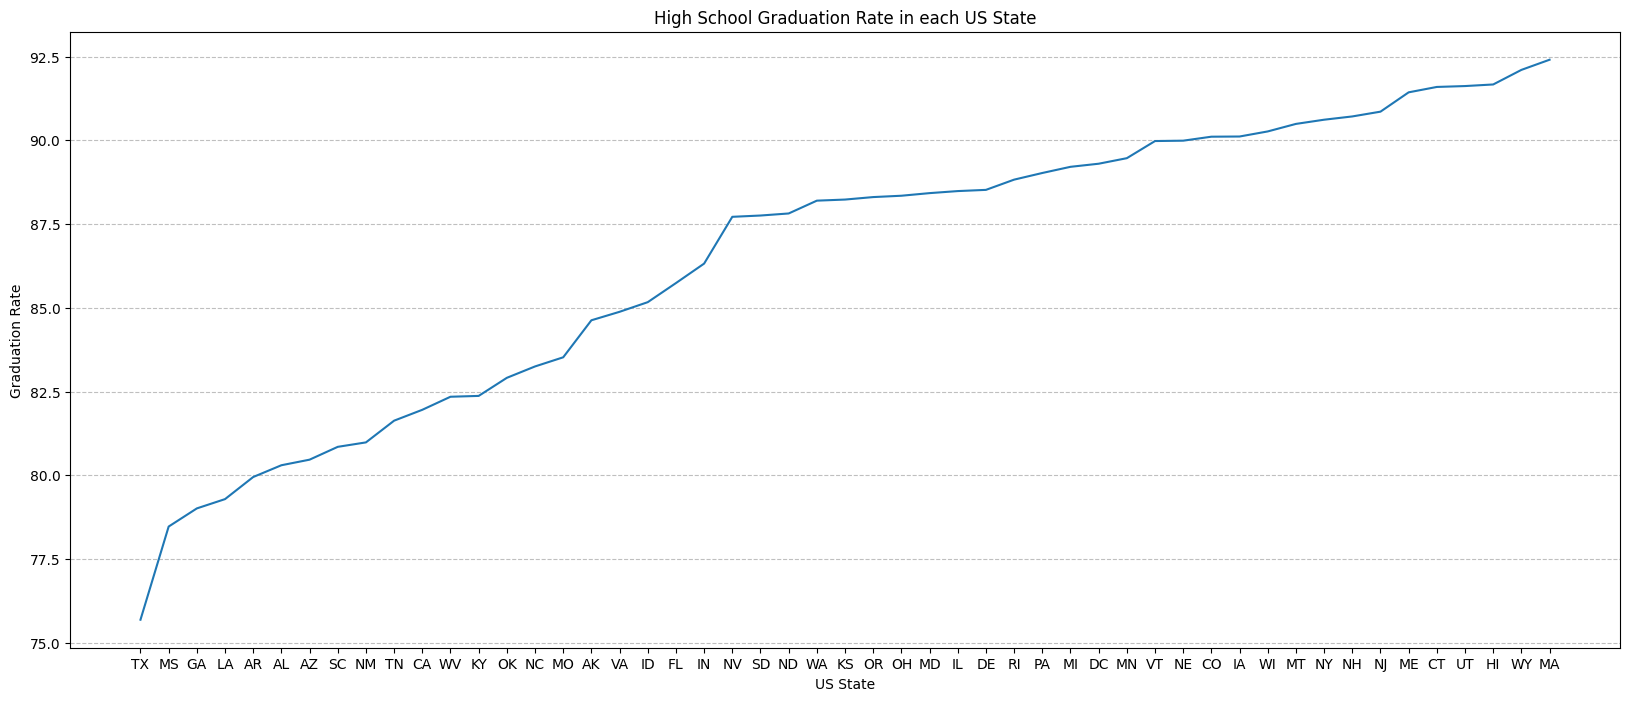

The state with the highest graduation rate is MA with a rate of 92.40%
The state with the lowest graduation rate is TX with a rate of 75.69%


In [83]:
plt.figure(figsize=(20, 8))
plt.plot(completed_hs_rate['Geographic Area'], completed_hs_rate['percent_completed_hs'])
plt.xlabel("US State")
plt.ylabel("Graduation Rate")
plt.title("High School Graduation Rate in each US State")
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.show()

print(f'The state with the highest graduation rate is {completed_hs_rate.iloc[-1]["Geographic Area"]} with a rate of {completed_hs_rate.iloc[-1]["percent_completed_hs"]:.2f}%')
print(f'The state with the lowest graduation rate is {completed_hs_rate.iloc[0]["Geographic Area"]} with a rate of {completed_hs_rate.iloc[0]["percent_completed_hs"]:.2f}%')

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [96]:
poverty_vs_grad_df = poverty_rate.merge(completed_hs_rate, on='Geographic Area') # Merge the two DataFrames on 'Geographic Area'
poverty_vs_grad_df.sort_values('percent_completed_hs', ascending=False, inplace=True) # Sort by graduation rate in descending order

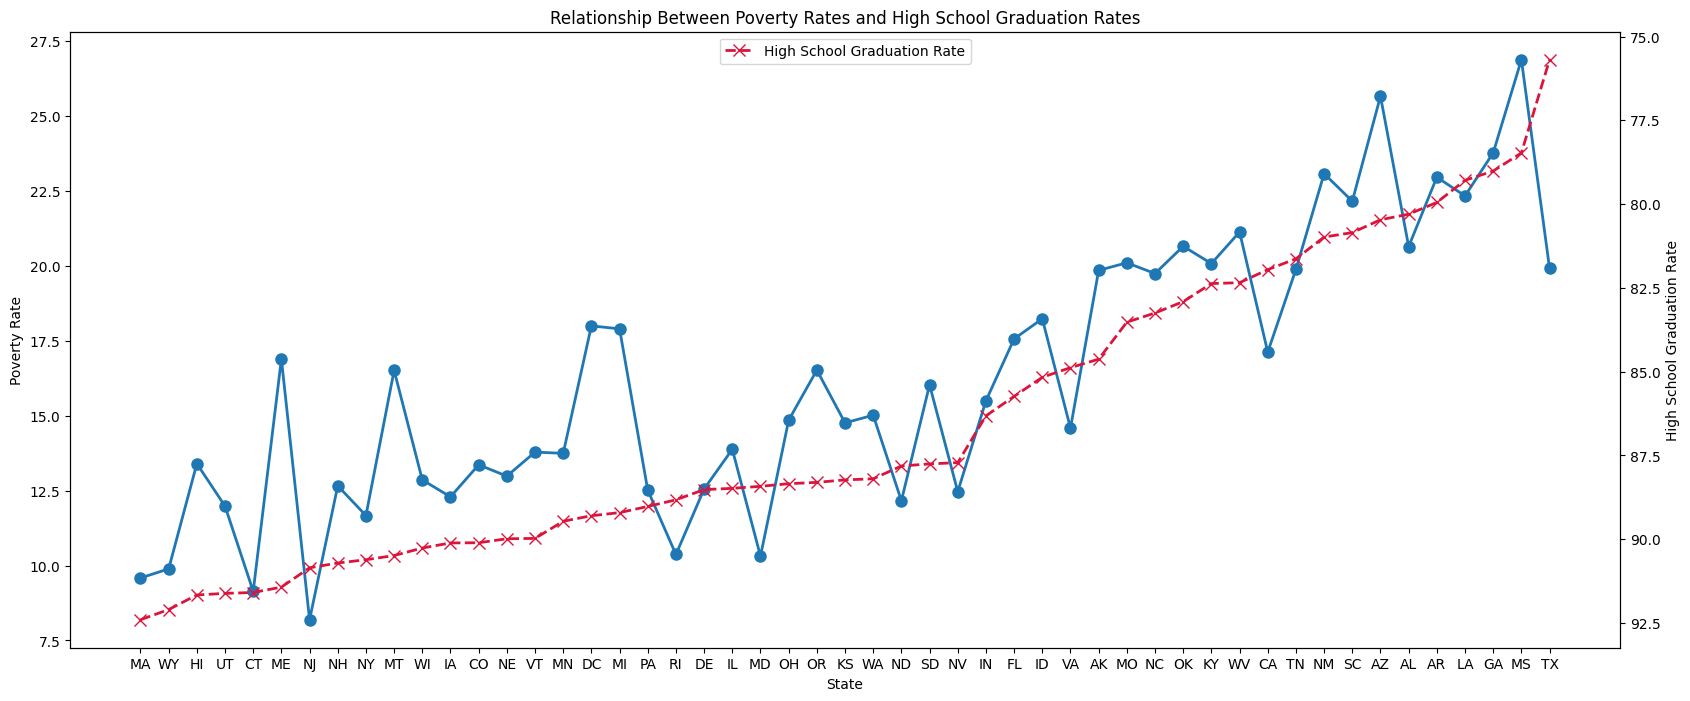

The plot above illustrates the inverse relationship between poverty rates and high school graduation rates across US states.
As the poverty rate increases, the high school graduation rate tends to decrease, indicating that higher poverty levels may be associated with lower educational attainment.


In [97]:
plt.figure(figsize=(20,8))
plt.title('Relationship Between Poverty Rates and High School Graduation Rates')

ax = plt.gca() # Get current axis
ax2 = ax.twinx() # Create a second y-axis

ax.plot(poverty_vs_grad_df['Geographic Area'], poverty_vs_grad_df['poverty_rate'], label='Poverty Rate', linestyle='-', marker='o', markersize=8, linewidth=2) # Plot poverty rate on primary y-axis

ax2.plot(poverty_vs_grad_df['Geographic Area'], poverty_vs_grad_df['percent_completed_hs'], color='crimson', label='High School Graduation Rate', linestyle='--', marker='x', markersize=8, linewidth=2) # Plot graduation rate on secondary y-axis

ax.set_ylabel('Poverty Rate')
ax.set_xlabel('State')
ax2.set_ylabel('High School Graduation Rate')

ax2.invert_yaxis() # Invert the secondary y-axis to show inverse relationship
plt.legend(loc='upper center')
ax.yaxis.grid(False)
ax2.grid(False)
plt.show()

print(f"The plot above illustrates the inverse relationship between poverty rates and high school graduation rates across US states.\nAs the poverty rate increases, the high school graduation rate tends to decrease, indicating that higher poverty levels may be associated with lower educational attainment.")

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

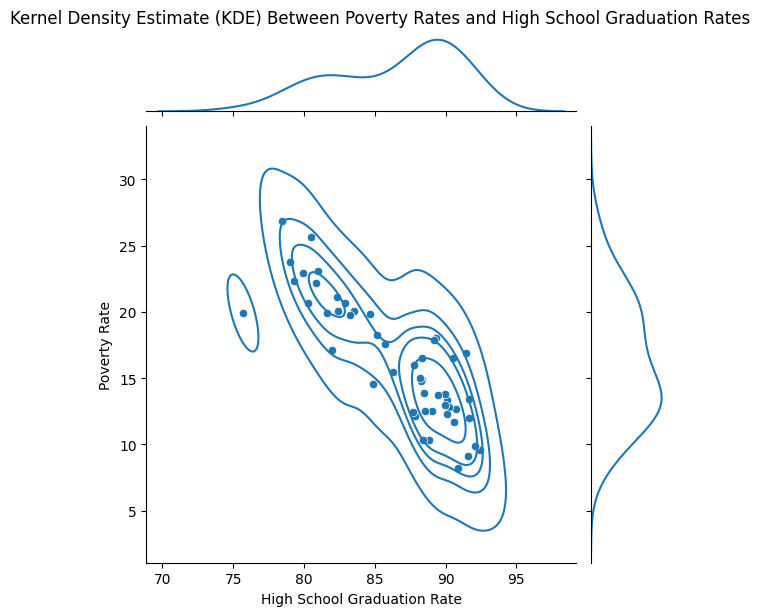

In [98]:
ax = sns.jointplot(poverty_vs_grad_df, x="percent_completed_hs", y="poverty_rate", kind='kde', levels=6) # Create a jointplot with KDE
ax1 = ax.plot_joint(sns.scatterplot) # Overlay a scatter plot on the jointplot

ax.fig.suptitle('Kernel Density Estimate (KDE) Between Poverty Rates and High School Graduation Rates', y=1.02) # Adjust title position

plt.xlabel("High School Graduation Rate")
plt.ylabel("Poverty Rate")

plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

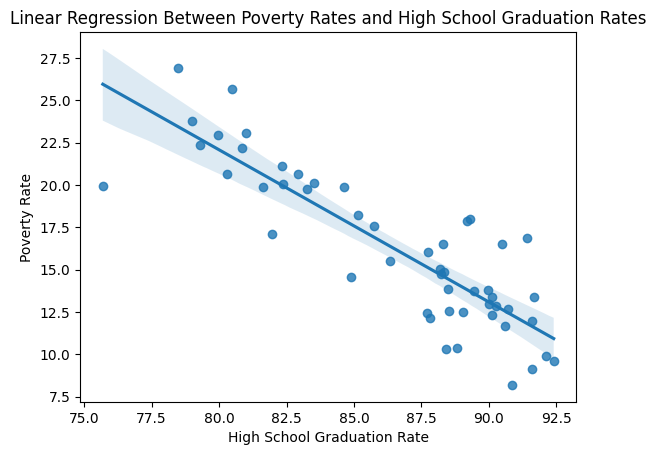

In [99]:
sns.regplot(poverty_vs_grad_df, x="percent_completed_hs", y="poverty_rate") # Create a regression plot

plt.xlabel("High School Graduation Rate")
plt.ylabel("Poverty Rate")
plt.title('Linear Regression Between Poverty Rates and High School Graduation Rates')

plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).